In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------


# One knob, two phenomena: azeotropes and phase splits

This notebook works **Problem 11.2-17**, which is the best single question in the chapter
for tying Chapter 10 to Chapter 11. A binary mixture has exactly one adjustable number —
the one-constant Margules parameter $A$ in $\underline{G}^{\rm ex} = A x_1 x_2$ — and two
completely different things happen as it is turned up:

* at modest $A$, the vapor-liquid diagram develops an **azeotrope**, which is Chapter 10;
* at large $A$, the liquid itself **splits into two phases**, which is Chapter 11.

The problem asks for both thresholds as functions of composition. What happens
where they meet is the result. **They are not independent**: for a mixture whose two
vapor pressures are far apart, the nonideality needed to make an azeotrope is more than
enough to split the liquid, and what you get instead is the three-phase behavior of
Section 11.3.

Both answers here are closed-form, on purpose: a formula that
matches a numerical solve to six figures is a much stronger check than either alone.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026


In [2]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from thermo.activity_models import OneConstantMargules, R
from thermo.charts import use_book_style
from thermo.vle import GammaPhi, TabulatedPsat, azeotrope
from thermo import lle

use_book_style()

BAR = 1e5
T = 350.0        # nothing in the problem fixes T; only the group A/RT matters


## (a) The $A$ that makes an azeotrope

At an azeotrope $y_i = x_i$, so the equilibrium relation
$x_i\gamma_i P_i^{\rm sat} = y_i P$ collapses to $\gamma_i P_i^{\rm sat} = P$ for **both**
species — the total pressure equals each species' own $\gamma_iP_i^{\rm sat}$. Dividing
one by the other kills the pressure:

$$\frac{\gamma_1}{\gamma_2} = \frac{P_2^{\rm sat}}{P_1^{\rm sat}}$$

For the one-constant Margules model, $RT\ln\gamma_1 = Ax_2^2$ and
$RT\ln\gamma_2 = Ax_1^2$, so $\ln(\gamma_1/\gamma_2) = A(x_2^2 - x_1^2)/RT
= A(1 - 2x_1)/RT$ and

$$\boxed{\;\frac{A}{RT} = \frac{\ln\left(P_2^{\rm sat}/P_1^{\rm sat}\right)}{1 - 2x_1}\;}$$

Read it as the problem asks: *given* where you want the azeotrope, this is the
nonideality it takes. Two consequences fall straight out of the algebra:

* an azeotrope at $x_1 = 0.5$ needs $P_1^{\rm sat} = P_2^{\rm sat}$ — the denominator
  vanishes;
* the further the azeotrope sits from $x_1 = 0.5$, and the further apart the two vapor
  pressures, the larger $A$ has to be.


In [3]:
def A_for_azeotrope(x1, ratio, T=T):
    """The Margules A (J/mol) that puts an azeotrope at x1, for P2sat/P1sat = ratio."""
    return R * T * np.log(ratio) / (1.0 - 2.0 * x1)

print(f"  {'P2/P1':>6s} {'x1 asked':>9s} {'A/RT':>8s} {'x1 found':>9s} {'P (bar)':>9s}")
for ratio, x1 in ((1.2, 0.42), (1.5, 0.35), (2.0, 0.30), (5.0, 0.20)):
    A = A_for_azeotrope(x1, ratio)
    gp = GammaPhi([TabulatedPsat(1.0 * BAR, T), TabulatedPsat(ratio * BAR, T)],
                  OneConstantMargules(A))
    x_az, P_az = azeotrope(gp, T=T)
    print(f"  {ratio:6.1f} {x1:9.2f} {A / (R * T):8.4f} {x_az:9.5f} {P_az / BAR:9.4f}")

   P2/P1  x1 asked     A/RT  x1 found   P (bar)
     1.2      0.42   1.1395   0.42000    1.4672
     1.5      0.35   1.3516   0.35000    1.7701
     2.0      0.30   1.7329   0.30000    2.3376
     5.0      0.20   2.6824   0.20000    5.5663



**The formula and the solver agree to five decimals at every ratio**, which is what a
closed form is for.

One more thing falls out of the same algebra, and it is Chapter 10's azeotrope criterion:
for the azeotropic composition to lie in $(0, 0.5)$ at all,

$$\frac{A}{RT} > \ln\frac{P_2^{\rm sat}}{P_1^{\rm sat}}
\qquad\text{that is}\qquad
\gamma_1^\infty = e^{A/RT} > \frac{P_2^{\rm sat}}{P_1^{\rm sat}}$$

An azeotrope forms when the infinite-dilution activity coefficient of the less volatile
species exceeds the vapor pressure ratio — a statement about a limit, recovered here from
a statement about a composition.

## (b) The $A$ that splits the liquid

There are **two** curves that could answer this, and choosing the wrong one gets part (b)
wrong. Section 11.2 derives the limit of *stability* from the curvature of
the Gibbs energy of mixing, Eq. 11.2-11,

$$\frac{1}{RT}\frac{\partial^2 \Delta_{\rm mix}\underline{G}}{\partial x_1^2}
  = \frac{1}{x_1x_2} - \frac{2A}{RT}
\qquad\Longrightarrow\qquad
\frac{A}{RT}\Big|_{\rm spinodal} = \frac{1}{2x_1x_2}$$

whose minimum is exactly **2** at $x_1 = 0.5$ — Eq. 11.2-14's $T_{uc} = A/2R$ seen from
the other side. But the spinodal is where a mixture becomes unstable to an *infinitesimal*
fluctuation. **The question part (b) asks — will a mixture of this composition split? —
is answered by the coexistence curve, which lies outside the spinodal.** Between the two a
mixture is metastable: still single-phase against small fluctuations, and still not the
equilibrium state.

For this model the coexistence curve is closed-form too. The mixture is symmetric, so
$x_1^{\rm II} = 1 - x_1^{\rm I}$, and putting that into $x_i^{\rm I}\gamma_i^{\rm I} =
x_i^{\rm II}\gamma_i^{\rm II}$ gives

$$\boxed{\;\frac{A}{RT}\Big|_{\rm binodal}
   = \frac{\ln\left[x_1/(1-x_1)\right]}{2x_1 - 1}\;}$$

which also tends to 2 as $x_1 \to 0.5$. That is the curve part (b) wants.


In [4]:
a_binodal  = lambda x1: np.log(x1 / (1 - x1)) / (2 * x1 - 1)      # closed form
a_spinodal = lambda x1: 1.0 / (2 * x1 * (1 - x1))                 # SIS Eq. 11.2-13

print(f"  {'x1':>5s} {'A/RT binodal':>13s} {'solved edges':>21s} {'A/RT spinodal':>15s}")
for x1 in (0.10, 0.20, 0.30, 0.40, 0.45):
    a = a_binodal(x1)
    lo, hi = lle.binary_lle(OneConstantMargules(a * R * T), T)
    print(f"  {x1:5.2f} {a:13.6f}   {lo[0]:9.6f} {hi[0]:9.6f} {a_spinodal(x1):15.6f}")

m2 = OneConstantMargules(2.0 * R * T)
print(f"\n  both curves meet at A/RT = 2, where the consolute temperature is "
      f"{lle.consolute_temperature(m2, (0.5 * T, 2 * T), xtol=1e-7):.3f} K "
      f"and T is {T:.1f} K  (Eq. 11.2-14)")

     x1  A/RT binodal          solved edges   A/RT spinodal
   0.10      2.746531    0.100000  0.900000        5.555556
   0.20      2.310491    0.200000  0.800000        3.125000
   0.30      2.118245    0.300000  0.700000        2.380952
   0.40      2.027326    0.400000  0.600000        2.083333
   0.45      2.006707    0.450000  0.550000        2.020202



  both curves meet at A/RT = 2, where the consolute temperature is 350.000 K and T is 350.0 K  (Eq. 11.2-14)



The closed form reproduces `binary_lle` to six decimals at every composition — and note how
much room there is between the two curves. At $x_1 = 0.2$ a mixture is already two phases
at $A/RT = 2.31$ but does not become *unstable* until 3.13.

## Putting them on one plot

Each solid curve is "the $A$ that puts an azeotrope here," one per vapor-pressure ratio.
The heavy dashed curve is the coexistence curve: above it, a liquid of that composition has
already separated in two. Where a solid curve crosses the dashed one, the azeotrope the
vapor-liquid equations predict sits at a composition the liquid cannot occupy.


  solid   the A that puts an azeotrope at x1, labeled by P2sat/P1sat
  dashed  the coexistence curve: above it the liquid is two phases
  dotted  the spinodal, SIS Eq. 11.2-13
  dots    where each azeotrope stops being a state the liquid can reach


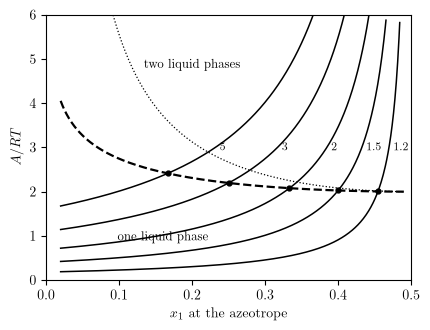

In [5]:
x = np.linspace(0.02, 0.49, 500)
ratios = (1.2, 1.5, 2.0, 3.0, 5.0)

fig, ax = plt.subplots(figsize=(4.4, 3.4))
ax.plot(x, a_binodal(x), "k--", lw=1.6)
ax.plot(x, a_spinodal(x), "k:", lw=0.9)

for r in ratios:
    y = np.log(r) / (1 - 2 * x)
    keep = y <= 6.0
    ax.plot(x[keep], y[keep], "k-", lw=1.1)
    xc = 1.0 / (1.0 + r)
    ax.plot([xc], [(1 + r) * np.log(r) / (r - 1)], "ko", ms=3.5)
    # label each curve where it passes A/RT = 3; labeling at the top edge instead
    # puts 1.2 and 1.5 within 0.02 of each other and they collide
    ax.text(0.5 * (1 - np.log(r) / 3.0) + 0.006, 3.0, f"{r:g}", fontsize=8,
            ha="left", va="center")

ax.text(0.20, 4.8, "two liquid phases", fontsize=9, ha="center")
ax.text(0.16, 0.9, "one liquid phase", fontsize=9, ha="center")
ax.set_xlabel(r"$x_1$ at the azeotrope")
ax.set_ylabel(r"$A/RT$")
ax.set_xlim(0, 0.5); ax.set_ylim(0, 6)
fig.tight_layout()

print("  solid   the A that puts an azeotrope at x1, labeled by P2sat/P1sat")
print("  dashed  the coexistence curve: above it the liquid is two phases")
print("  dotted  the spinodal, SIS Eq. 11.2-13")
print("  dots    where each azeotrope stops being a state the liquid can reach")


## Where the two conditions cross

Setting the two boxed results equal,

$$\frac{\ln\left(P_2^{\rm sat}/P_1^{\rm sat}\right)}{1 - 2x_1}
  = \frac{\ln\left[x_1/(1-x_1)\right]}{2x_1 - 1}
\qquad\Longrightarrow\qquad
\frac{P_2^{\rm sat}}{P_1^{\rm sat}} = \frac{1-x_1}{x_1}$$

**The whole comparison the problem asks for collapses to one line.** The azeotrope
reaches the coexistence curve at

$$x_1^* = \frac{P_1^{\rm sat}}{P_1^{\rm sat} + P_2^{\rm sat}}
\qquad\text{where}\qquad
\frac{A}{RT}\Big|^* = \frac{(1+r)\ln r}{r-1}, \quad r = P_2^{\rm sat}/P_1^{\rm sat}$$

and that composition should look familiar: $P_1^{\rm sat}/(P_1^{\rm sat} + P_2^{\rm sat})$
is the vapor composition over two **completely immiscible** liquids, Eq. 11.3-3. The
azeotrope stops being a single-liquid state exactly when it arrives at the composition the
two-liquid system would boil at anyway.

So part (b)'s answer is a window, both ends closed-form:

$$\ln r \;<\; \frac{A}{RT} \;<\; \frac{(1+r)\ln r}{r - 1}$$

Below the lower bound there is no azeotrope; above the upper bound there is no single
liquid.


In [6]:
print(f"  {'P2/P1':>6s} {'no azeotrope below':>19s} {'x1*':>8s} "
      f"{'no single liquid above':>23s} {'binodal edge at A*':>20s}")
for r in (1.2, 1.5, 2.0, 3.0, 5.0, 20.0):
    xc = 1.0 / (1.0 + r)
    ac = (1 + r) * np.log(r) / (r - 1)
    lo, hi = lle.binary_lle(OneConstantMargules(ac * R * T), T)
    print(f"  {r:6.1f} {np.log(r):19.4f} {xc:8.4f} {ac:23.4f} {lo[0]:20.4f}")

   P2/P1  no azeotrope below      x1*  no single liquid above   binodal edge at A*
     1.2              0.1823   0.4545                  2.0055               0.4545
     1.5              0.4055   0.4000                  2.0273               0.4000
     2.0              0.6931   0.3333                  2.0794               0.3333
     3.0              1.0986   0.2500                  2.1972               0.2500
     5.0              1.6094   0.1667                  2.4142               0.1667
    20.0              2.9957   0.0476                  3.3111               0.0476



The last two columns are the check: at $A^*$ the coexistence curve's own edge lands on
$x_1^*$, to four figures, over a range of ratios spanning a factor of twenty.

## The same mixture on both sides of that line

Take $P_2^{\rm sat}/P_1^{\rm sat} = 5$, where the window is $1.609 < A/RT < 2.414$, and ask
for an azeotrope on each side of it. The vapor-liquid solver converges both times — it has no way to know that one of its two answers is not a state the liquid can
reach.


In [7]:
r = 5.0
for x_asked in (0.12, 0.20):
    A = A_for_azeotrope(x_asked, r)
    m = OneConstantMargules(A)
    gp = GammaPhi([TabulatedPsat(1.0 * BAR, T), TabulatedPsat(r * BAR, T)], m)
    x_az, P_az = azeotrope(gp, T=T)
    lo, hi = lle.binary_lle(m, T)
    real = x_az < lo[0] or x_az > hi[0]
    print(f"  A/RT = {A / (R * T):.4f}:  azeotrope at x1 = {x_az:.4f}, "
          f"P = {P_az / BAR:.3f} bar")
    print(f"     liquid coexistence {lo[0]:.4f} .. {hi[0]:.4f}   -> "
          f"{'a real azeotrope' if real else 'INSIDE the two-phase region'}")

d = lle.pxy_lle(gp, T, n=401)
print(f"\n  for the second one, what exists instead is a three-phase line at "
      f"{d['P_vlle'] / BAR:.3f} bar,")
print(f"  with a vapor of y1 = {d['y_vlle'][0]:.4f} in equilibrium with both liquids")
print(f"  -- the completely-immiscible value P1/(P1 + P2) is {1 / (1 + r):.4f}")

  A/RT = 2.1177:  azeotrope at x1 = 0.1200, P = 5.155 bar
     liquid coexistence 0.3004 .. 0.6996   -> a real azeotrope
  A/RT = 2.6824:  azeotrope at x1 = 0.2000, P = 5.566 bar
     liquid coexistence 0.1097 .. 0.8903   -> INSIDE the two-phase region

  for the second one, what exists instead is a three-phase line at 5.517 bar,
  with a vapor of y1 = 0.1667 in equilibrium with both liquids
  -- the completely-immiscible value P1/(P1 + P2) is 0.1667



**The second one is a heteroazeotrope**, and it is what Section 11.3 is about: the
mixture boils at constant temperature and constant vapor composition, like an azeotrope,
but the liquid it boils from is two liquids. Figure 11.3-2's isobutane-furfural system is a
real instance, and Illustration 11.3-1 computes it.

Note what the vapor-liquid solver did on its own: it returned a perfectly convergent
azeotrope at a composition where no single liquid phase exists. **A vapor-liquid
calculation cannot tell that its liquid is unstable** — which is exactly why Section 11.3
gives the working rule that a computed $P$–$x$ curve carrying both a maximum and a minimum
should be followed by a liquid-liquid calculation.

## Your turn

1. Redo part (a) for the **two**-constant Margules or van Laar model, where the two activity
   coefficients are no longer mirror images. Does the azeotrope condition still collapse to
   a single formula, and does the coexistence curve still have a closed form?
2. The window $\ln r < A/RT < (1+r)\ln r/(r-1)$ narrows relative to its lower end as $r$
   grows. Plot both bounds against $r$ and say what that means for a mixture of two very
   differently volatile species.
3. Everything here is at fixed $T$ through the group $A/RT$. For a real mixture $A$ is
   roughly constant while $P^{\rm sat}$ and $RT$ both move. Take a pair of Antoine constants
   from the appendices, hold $A$ fixed, and find the temperature at which the azeotrope
   disappears.
4. Draw the full $P$–$x$–$y$ diagram for the $A/RT = 2.68$ case with `lle.pxy_lle`, and mark
   on it the fictitious azeotrope the vapor-liquid solver reported.
5. The crossing composition $x_1^* = P_1^{\rm sat}/(P_1^{\rm sat}+P_2^{\rm sat})$ is also the
   vapor composition over two immiscible liquids. Show that this is not a coincidence by
   taking the limit $A/RT \to \infty$ in the azeotrope condition.
6. Problem 11.2-1 asks for the same two thresholds for the **regular solution** model. Its
   consolute temperature is not $A/2R$ — work out what replaces the 2, and check it with
   `lle.consolute_temperature`.
